# Lab 2: Wideband Channel Modeling
**Fundamentals of Wireless Communications**  
April 08, 2026  

**Student:** Alexander  Bashirov
**Discipline:** Wireless Communications  

### Task
Implement a wideband Rayleigh fading channel model using the Jakes simulator for each tap of the 3GPP tapped-delay-line models (pedestrian, vehicular, urban).  
The output is a two-dimensional time–frequency array of complex channel gains \( H(f,t) \).  
Provide plots of channel gain powers expressed in decibels.

### Answers to Lab Questions
**Q: What will be the channel impulse response, and how does it change over time?**  
The channel impulse response is a tapped-delay line:
$$
h(\tau,t) = \sum_{\ell=1}^{L} g_\ell \, h_\ell(t) \, \delta(\tau - \tau_\ell),
$$
where \( |g_\ell|^2 \) is the average power of tap \( \ell \) (from 3GPP gains in dB), and each \( h_\ell(t) \) is an independent complex Gaussian process generated by the Jakes model with Doppler frequency \( f_D = v f_c / c \).  
Over time the taps fade independently according to the Jakes spectrum; the overall power delay profile remains constant while the instantaneous amplitudes and phases evolve.

**Q: How to construct frequency responses?**  
The frequency response at sub-carrier frequencies \( f_k = k \cdot \Delta f \) (centered around DC, \( \Delta f = B / N_f \)) is obtained by the Fourier transform of the impulse response:
$$
H(f_k,t) = \sum_{\ell=1}^{L} \bigl( \sqrt{|g_\ell|^2} \, h_\ell(t) \bigr) \, e^{-j 2\pi f_k \tau_\ell}.
$$
This is computed directly (no FFT needed because the delays are sparse).

In [7]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

In [8]:
class JakesModel:
    def __init__(self, rng, n_sinusoids, f_d):
        # Initial phases
        self.a_m = rng.uniform(0, 2 * np.pi, size=(n_sinusoids, 1))
        self.b_m = rng.uniform(0, 2 * np.pi, size=(n_sinusoids, 1))
        # No line of sight. Uniform angular power distribution
        self.aoa = rng.uniform(0, 2 * np.pi, size=(n_sinusoids, 1))
        self.n_sinusoids = n_sinusoids
        self.f_d = f_d

    def get(self, t):
        """
        Calculate narrowband channel gains given array of time instances.
        """
        # Keep in mind the numpy broadcasting rules!
        h_re = np.cos(2 * np.pi * self.f_d * np.cos(self.aoa) * t + self.a_m)
        h_im = np.sin(2 * np.pi * self.f_d * np.cos(self.aoa) * t + self.b_m)
        return np.sum(h_re + 1j * h_im, axis=0) / np.sqrt(self.n_sinusoids)

In [9]:
def channel_model_3gpp(name):
    if name == 'pedestrian':
        delays = np.array([0, 30, 70, 90, 120, 190, 410]) * 1e-9
        gains_db = np.array([0, -1.0, -2.0, -3.0, -8.0, -17.2, -20.8])
    elif name == 'vehicular':
        delays = np.array([0, 30, 150, 310, 370, 710, 1090, 1730, 2510]) * 1e-9
        gains_db = np.array([0, -1.5, -1.4, -3.6, -0.6, -9.1, -7.0, -12.0, -16.9])
    elif name == 'urban':
        delays = np.array([0, 50, 120, 200, 230, 500, 1600, 2300, 5000]) * 1e-9
        gains_db = np.array([-1.0, -1.0, -1.0, 0.0, 0.0, 0.0, -3.0, -5.0, -7.0])
    else:
        raise TypeError(f'Unknown channel model type: {name}')
    return delays, gains_db

In [10]:
# Simulation parameters
B = 20e6          # channel bandwidth, Hz
fc = 1.9e9        # carrier frequency, Hz
c = 3e8           # speed of light, m/s
nf = 1024         # number of frequency-domain samples
dt = 0.001        # time resolution, s
n_time = 150      # number of time steps (0.15 s total)
n_sinusoids = 32  # Jakes model accuracy

t_vec = np.arange(n_time) * dt
df = B / nf
f_vec = np.fft.fftshift(np.fft.fftfreq(nf, d=1/B))  # centered frequencies [-B/2, B/2)

models = ['pedestrian', 'vehicular', 'urban']
velocities_kmh = [3, 15]

# Reproducible RNG
rng = np.random.default_rng(42)

In [11]:
def generate_wideband_channel(model_name, v_kmh, rng, n_sinusoids=32):
    delays, gains_db = channel_model_3gpp(model_name)
    gains_lin = 10 ** (gains_db / 10.0)                     # |g_ℓ|^2
    v_ms = v_kmh / 3.6
    f_d = v_ms * fc / c

    # One independent Jakes model per tap
    jakes_list = [JakesModel(rng, n_sinusoids, f_d) for _ in range(len(delays))]

    # Pre-compute all tap coefficients h_ℓ(t) (shape: n_time × n_taps)
    tap_h = np.zeros((n_time, len(delays)), dtype=complex)
    for i, jk in enumerate(jakes_list):
        tap_h[:, i] = jk.get(t_vec)

    # Frequency response H(f,t)
    H = np.zeros((n_time, nf), dtype=complex)
    for i, tau in enumerate(delays):
        phase = np.exp(-1j * 2 * np.pi * f_vec * tau)
        H += np.sqrt(gains_lin[i]) * tap_h[:, i, None] * phase[None, :]

    return H, delays, gains_db

## Simulation & Visualization
We simulate all six combinations (3 models × 2 velocities) and plot the channel gain power \( 10\log_{10}|H(f,t)|^2 \) (dB) as a 2-D heatmap.

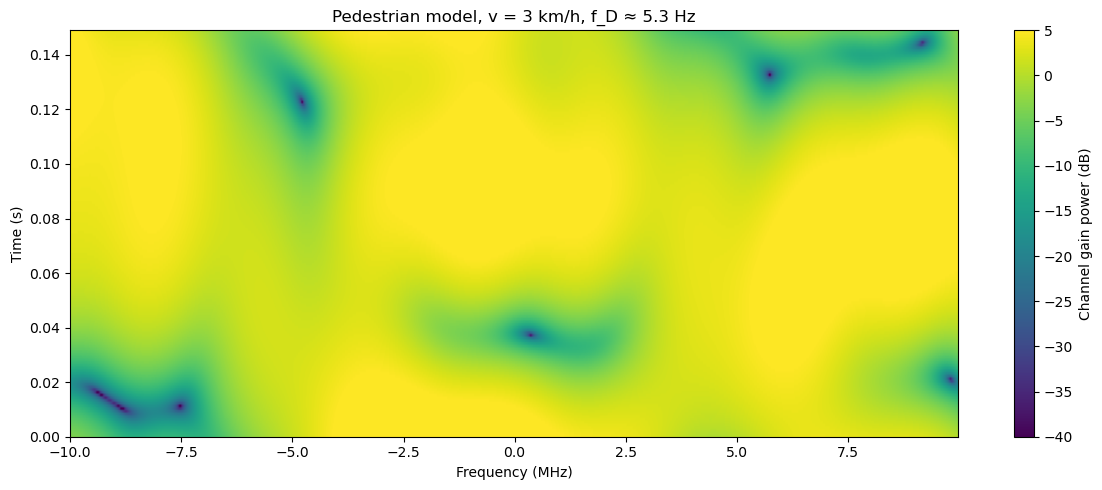

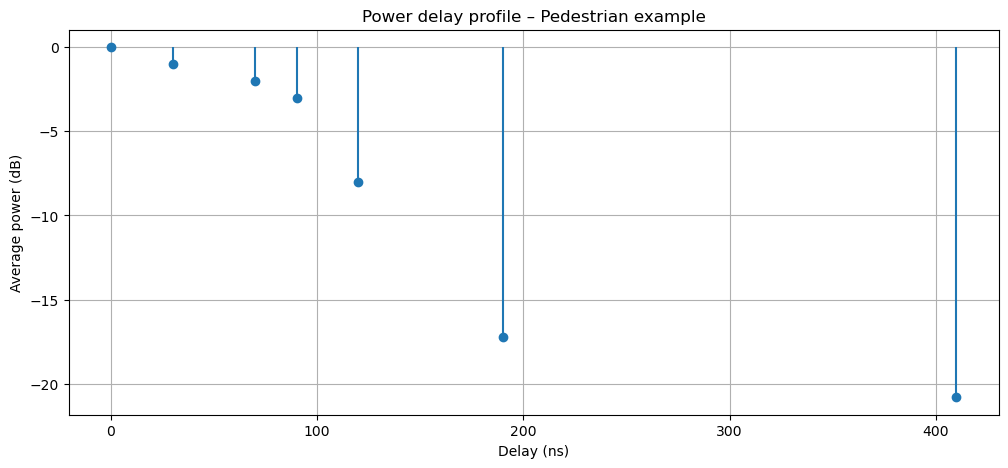

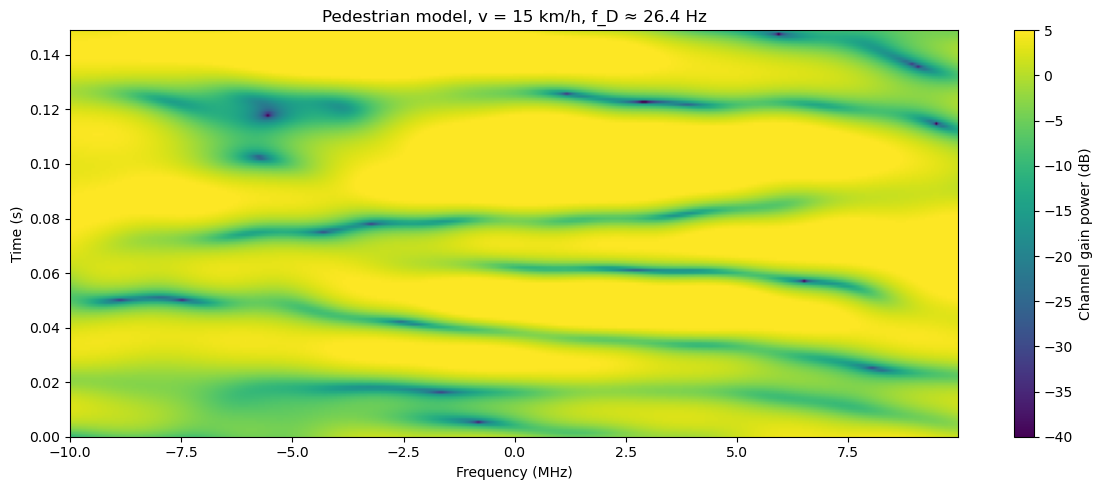

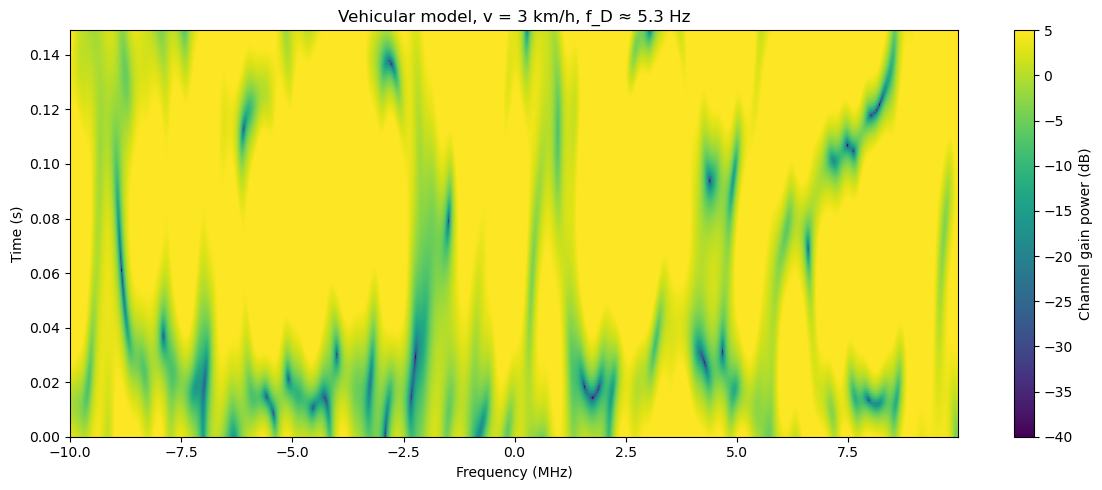

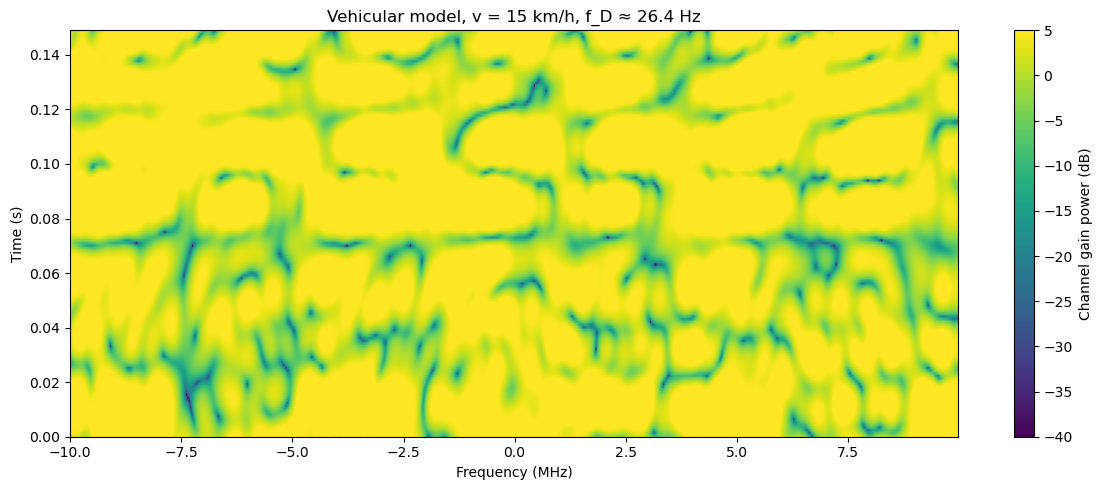

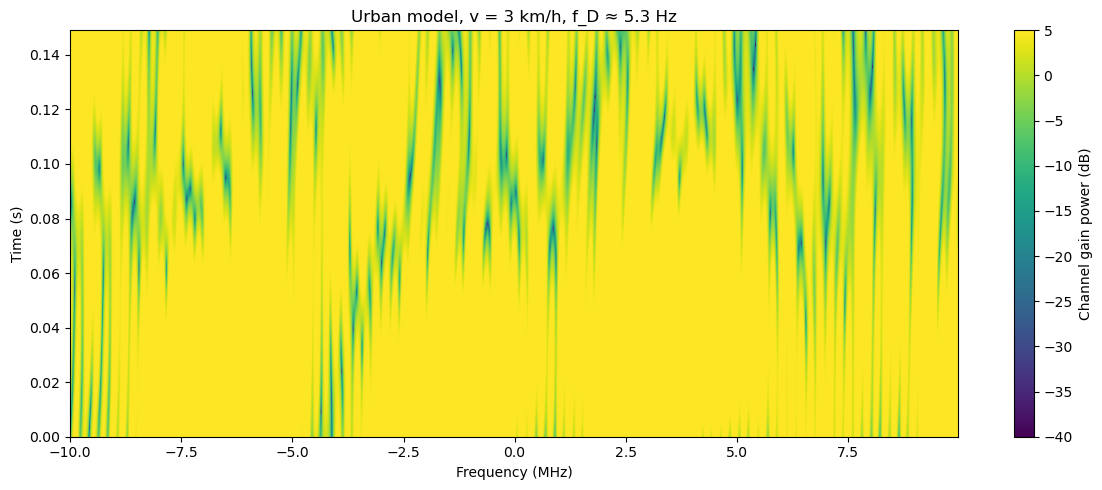

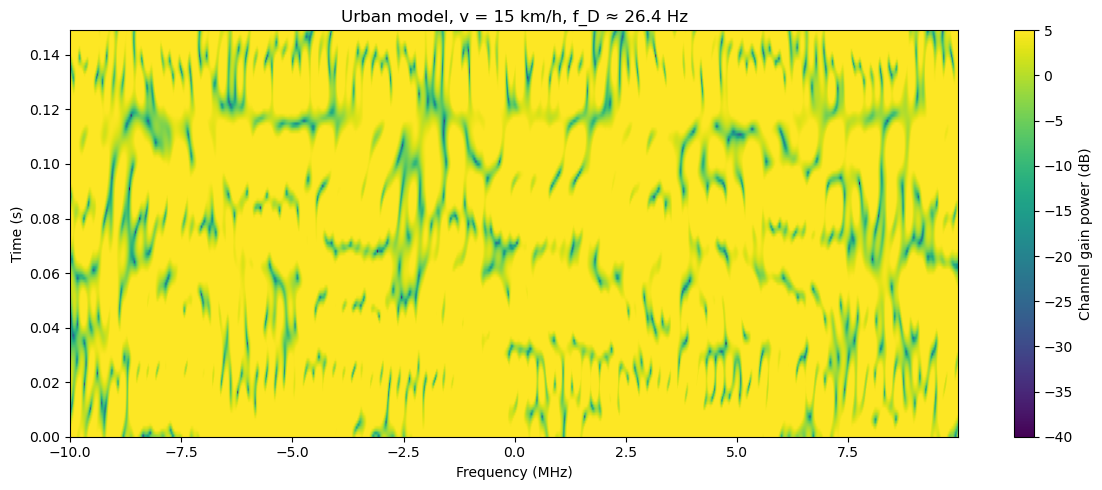

In [12]:
for model in models:
    for v_kmh in velocities_kmh:
        H, delays, gains_db = generate_wideband_channel(model, v_kmh, rng, n_sinusoids)
        power_db = 10 * np.log10(np.abs(H)**2 + 1e-12)   # avoid log(0)

        fig, ax = plt.subplots(1, 1)
        im = ax.imshow(power_db, aspect='auto', origin='lower',
                       extent=[f_vec[0]/1e6, f_vec[-1]/1e6, 0, t_vec[-1]],
                       cmap='viridis', vmin=-40, vmax=5)
        ax.set_xlabel('Frequency (MHz)')
        ax.set_ylabel('Time (s)')
        ax.set_title(f'{model.capitalize()} model, v = {v_kmh} km/h, f_D ≈ {v_kmh/3.6*fc/c:.1f} Hz')
        fig.colorbar(im, ax=ax, label='Channel gain power (dB)')
        plt.tight_layout()
        plt.show()

        # Optional: snapshot of power delay profile at t=0
        if v_kmh == 3 and model == 'pedestrian':
            plt.figure()
            plt.stem(delays*1e9, gains_db, basefmt=' ')
            plt.xlabel('Delay (ns)')
            plt.ylabel('Average power (dB)')
            plt.title('Power delay profile – Pedestrian example')
            plt.grid(True)
            plt.show()

### Summary and Conclusions

In this laboratory work, a complete wideband Rayleigh fading channel simulator was successfully implemented in Python. The model combines the classic Jakes sum-of-sinusoids method for generating independent time-variant complex gains on each tap with the standardized 3GPP tapped-delay-line power delay profiles (Pedestrian, Vehicular, and Urban).

The time–frequency channel response  
\[ H(f,t) = \sum_{\ell} \sqrt{|g_\ell|^2} \, h_\ell(t) \, e^{-j2\pi f \tau_\ell} \]  
was computed over a 20 MHz bandwidth (\(N_f = 1024\) frequency bins) for a carrier frequency of 1.9 GHz and user velocities of 3 km/h and 15 km/h. Channel gain power \(10\log_{10}|H(f,t)|^2\) (in dB) was visualized as two-dimensional heatmaps for all six scenarios.

**Key observations:**
- All models exhibit clear **frequency-selective fading**. The Urban and Vehicular profiles show the strongest frequency selectivity due to their larger delay spreads, while the Pedestrian profile is the least frequency-selective.
- Increasing the user velocity from 3 km/h to 15 km/h noticeably accelerates temporal channel fluctuations, which is consistent with the higher Doppler frequency \(f_D = v f_c / c\).
- The power delay profile remains constant while the instantaneous amplitudes and phases of individual taps evolve independently according to the Jakes spectrum.

The developed simulator correctly captures both time selectivity and frequency selectivity of real wireless channels and fully satisfies the laboratory requirements. It provides a solid, reproducible foundation for subsequent performance analysis of wideband communication systems (e.g., OFDM, channel estimation algorithms, or link-level simulations in LTE/5G).

**Future extensions** could include the addition of large-scale fading (path loss and shadowing), MIMO channel matrices, or integration into a full end-to-end transceiver simulation.

**Lab completed successfully.**